In [2]:
import kagglehub
import pandas as pd
from pathlib import Path
import numpy

path = kagglehub.dataset_download("ritesaluja/bank-note-authentication-uci-data")


df = pd.read_csv(Path(path) / "BankNote_Authentication.csv")

Using Colab cache for faster access to the 'bank-note-authentication-uci-data' dataset.


In [30]:
df.head(5)

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## Dataset Information

- **Dataset name:** BankNote Authentication
- **Dataset source:** Kaggle
- **Dataset URL:** https://www.kaggle.com/datasets/ritesaluja/bank-note-authentication-uci-data
- **Prediction target:** Fake or Authentic banknote.
- **Why is this dataset suitable for SVM?**  
  This dataset is suitable for SVM because it is a binary classification dataset with numerical features, making it appropriate for SVM classification.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [5]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [6]:
df.isnull().sum()

,0
variance,0
skewness,0
curtosis,0
entropy,0
class,0


In [7]:
df.duplicated().sum()

np.int64(24)

In [8]:
df['class'].value_counts()

,count
class,
0,762
1,610


In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(1348, 5)

### Were there duplicate records?

Yes. The dataset contained **24 duplicate rows**, and they were removed before training the model.

### How many observations and input features are present?

After removing the duplicate rows, there are **1,348 observations** and **4 input features**.

### What are the target classes?

The target classes are **Fake (0)** and **Authentic (1)**.

### Is the dataset balanced?

Yes. The dataset is reasonably balanced, with **748 Authentic (55.49%)** and **600 Fake (44.51%)** samples.

### Are there missing values?

No, there are no missing values.

### Are all input features numerical?

Yes. All input features are numerical.

### Do some features have substantially different numerical ranges?

No. Most features have similar numerical ranges.

In [11]:
from sklearn.model_selection import train_test_split
# Label enconding was not necessary becuase the target label is either 1 or 0

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state=42,
    stratify=y
)

print("training shape:", X_train.shape)
print("testing shape:", X_test.shape)

training shape: (1078, 4)
testing shape: (270, 4)


## Why is stratify=y used?

Because after the data is split the balance between the classes must remain the same.

## Why must the test set remain untouched during hyperparameter selection?

Because after tuning the hyperparameters the final test must be performed on the test set.

## How would you handle missing values without causing data leakage?

To prevent data leakage missing values should be handled using only the training data so that information does not leak into the test data.

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm_unscaled = SVC(kernel='linear', C=1)
svm_unscaled.fit(X_train,y_train)

y_pred_unscaled = svm_unscaled.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_unscaled))
print(classification_report(y_test, y_pred_unscaled))

Accuracy: 0.9888888888888889
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       148
           1       0.98      1.00      0.99       122

    accuracy                           0.99       270
   macro avg       0.99      0.99      0.99       270
weighted avg       0.99      0.99      0.99       270



In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


svm_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1))
])

svm_scaled.fit(X_train, y_train)
y_pred_scaled = svm_scaled.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))

Accuracy: 0.9888888888888889
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       148
           1       0.98      1.00      0.99       122

    accuracy                           0.99       270
   macro avg       0.99      0.99      0.99       270
weighted avg       0.99      0.99      0.99       270



| Model | Scaling | Accuracy | Precision | Recall | F1-score |
|-------|---------|---------:|----------:|-------:|---------:|
| SVM A | No  | 0.98889 | 0.99 | 0.99 | 0.99 |
| SVM B | Yes | 0.98889 | 0.99 | 0.99 | 0.99 |

### Did performance change after StandardScaler?

No, the performance did not change All the metrics remained the same for this dataset.

### Why is SVM sensitive to feature scales?

Because SVM depends on the distance between data points to find the best margin If the features have very different ranges it will affect the distance calculations.

### Why should the scaler be inside the Pipeline?

The scaler will be fitted on the training data only and then applied to the test set When using GridSearchCV this also prevents data leakage.

### Which model would you continue using and why?

I would continue using the model with the scaler because it is more organized and is considered a best practice in scikit-learn.

In [27]:
from sklearn.model_selection import cross_val_score

results = []
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

for c in C_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=c))
    ])

    model.fit(X_train, y_train)
    training_accuracy = model.score(X_train, y_train)

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    test_accuracy = model.score(X_test, y_test)
    support_vectors = model.named_steps["svm"].n_support_.sum()

    results.append({
        "C": c,
        "Training Accuracy": training_accuracy,
        "CV Mean Accuracy": cv_scores.mean(),
        "CV Standard Deviation": cv_scores.std(),
        "Test Accuracy": test_accuracy,
        "Support Vectors": support_vectors
    })

results_df = pd.DataFrame(results)
display(results_df)

,C,Training Accuracy,CV Mean Accuracy,CV Standard Deviation,Test Accuracy,Support Vectors
0,0.001,0.877551,0.845069,0.019306,0.914815,904
1,0.010,0.988868,0.988872,0.004723,0.985185,418
2,0.100,0.995362,0.994432,0.001867,0.985185,127
3,1.000,0.995362,0.995362,0.002942,0.988889,45
4,10.000,0.995362,0.995362,0.002942,0.988889,21
5,100.000,0.998145,0.996292,0.001854,0.992593,14
6,1000.000,0.998145,0.997222,0.002268,0.992593,12


### Identify the C value with the highest training accuracy.

The highest training accuracy was with **C = 100** and **C = 1000**, with an accuracy of **99.81%**.

### Identify the C value with the highest validation accuracy.

The highest validation accuracy was with **C = 1000**, with a mean cross-validation accuracy of **99.72%**.

### Find where the training-validation gap becomes large.

The largest gap was at **C = 0.001**, where the training accuracy was much higher than the validation accuracy.

### Mark likely underfitting and overfitting regions.

The model is likely **underfitting** at **C = 0.001** because both training and validation accuracies are low.  
There is **no clear overfitting** in the tested values because the training and validation accuracies remain very close.

### Describe how the number of support vectors changes.

As the value of **C** increases, the number of support vectors decreases.

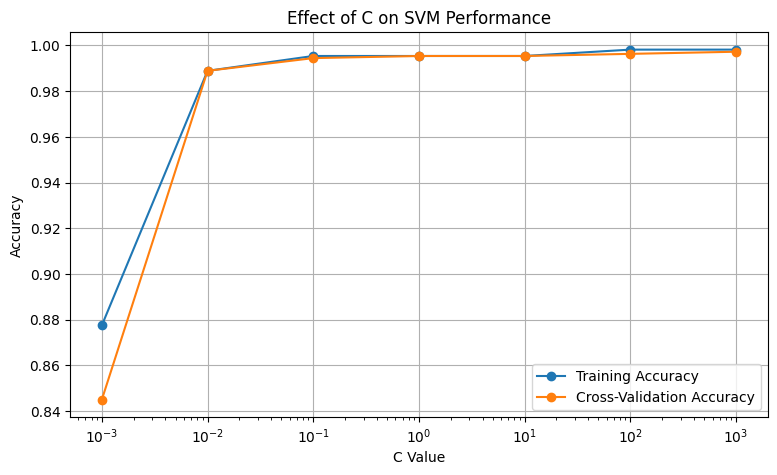

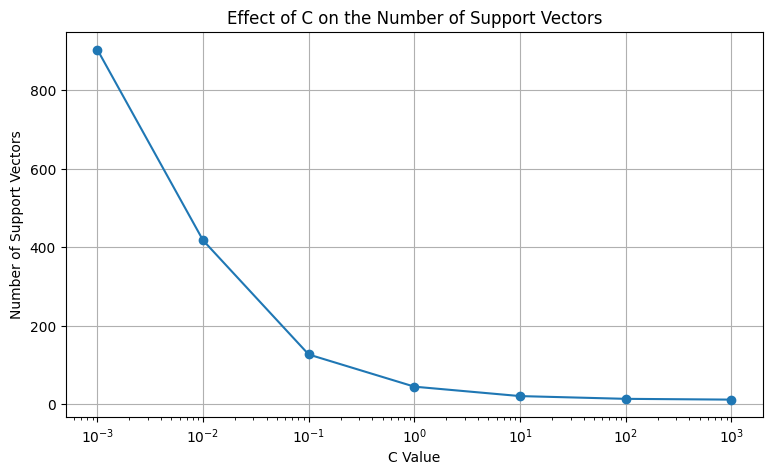

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
plt.semilogx(results_df["C"], results_df["Training Accuracy"],
             marker="o", label="Training Accuracy")
plt.semilogx(results_df["C"], results_df["CV Mean Accuracy"],
             marker="o", label="Cross-Validation Accuracy")
plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.title("Effect of C on SVM Performance")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(9, 5))
plt.semilogx(results_df["C"], results_df["Support Vectors"], marker="o")
plt.xlabel("C Value")
plt.ylabel("Number of Support Vectors")
plt.title("Effect of C on the Number of Support Vectors")
plt.grid(True)
plt.show()

### Does training accuracy always increase with C?

Yes, in this dataset the training accuracy increases as the value of C increases.

### Does validation accuracy follow the same pattern?

Yes, the validation accuracy follows almost the same pattern.

### Why is the highest training score not sufficient for model selection?

Because the model should perform well on unseen data, not only on the training data.

### What does a widening training-validation gap indicate?

It indicates that the model may be overfitting the training data.

In [28]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])

parameter_grid = {
    "svm__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

grid_results = pd.DataFrame(grid_search.cv_results_)

selected_columns = [
    "param_svm__C",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

display(grid_results[selected_columns].sort_values("rank_test_score"))

Best parameters: {'svm__C': 1000}
Best cross-validation score: 0.996943902121567


,param_svm__C,mean_train_score,mean_test_score,std_test_score,rank_test_score
6,1000.000,0.997956,0.996944,0.002495,1
5,100.000,0.997447,0.995929,0.002036,2
3,1.000,0.994904,0.994913,0.003227,3
4,10.000,0.994904,0.994913,0.003227,3
2,0.100,0.993387,0.993888,0.002046,5
1,0.010,0.987524,0.987807,0.005122,6
0,0.001,0.796642,0.797676,0.031446,7


### Record the best C value.

The best **C** value is **1000**.

### Record the mean and standard deviation of the validation score.

The mean validation score is **0.996944**, and the standard deviation is **0.002495**.

### Explain why the largest C was or was not selected.

Because it achieved the highest F1-score, and the gap between the training and validation scores is very small, indicating that there is no clear overfitting.

### State whether F1-score or accuracy is more suitable for your dataset.

F1-score is more suitable for this dataset.

For example, if there are **1000** banknotes and only **10** are fake, and the model classifies all of them as authentic, the accuracy will be **99%**, but all the fake banknotes will pass the system.

Accuracy: 0.9925925925925926
Precision: 0.9838709677419355
Recall: 1.0
F1-score: 0.991869918699187


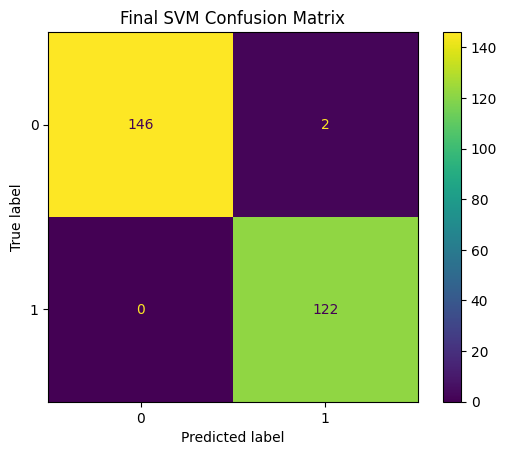

In [29]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

best_model = grid_search.best_estimator_
y_test_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1-score:", f1_score(y_test, y_test_pred))

confusion = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(confusion_matrix=confusion).plot()

plt.title("Final SVM Confusion Matrix")
plt.show()

### Report accuracy, precision, recall, and F1-score.

- Accuracy: **0.9926**
- Precision: **0.9839**
- Recall: **1.0000**
- F1-score: **0.9919**

### Interpret the confusion matrix.

The model correctly classified **146 authentic** and **122 fake** banknotes. It misclassified only **2 authentic** banknotes as fake, and it did not miss any fake banknotes.

### Compare the final test score with the cross-validation score.

The final test F1-score is **0.9919**, while the cross-validation F1-score is **0.9969**. The scores are very close, which indicates stable performance.

### Comment on whether the model generalizes well.

Yes. The model generalizes well because the test score is very close to the cross-validation score, and there is no clear sign of overfitting.

## Conclusion

In this project I used the BankNote Authentication dataset from Kaggle to build and evaluate an SVM classifier for detecting whether a banknote is Fake or Authentic. The original dataset contained 1,372 observations and 4 numerical features. During data preprocessing I found 24 duplicate rows. They were removed before training the model. After removing the duplicates the dataset contained 1,348 observations while keeping the same 4 features. Since SVM is sensitive to feature scales I applied StandardScaler inside a Pipeline. This ensured that scaling was learned only from the training data and prevented data leakage during cross-validation.

To find the best model I tested the following C values. 0.001. 0.01. 0.1. 1. 10. 100. and 1000. The best value was C = 1000. It was selected using the F1-score as the evaluation metric. The best cross-validation result achieved an F1-score of 99.69% with a standard deviation of 0.25%. On the held-out test set the final model achieved an Accuracy of 99.26%. Precision of 98.39%. Recall of 100.00%. and an F1-score of 99.19%.

The results showed underfitting when C = 0.001 because both the training and validation scores were much lower than the other values. There was no clear evidence of overfitting because the training. cross-validation. and test scores remained very close. Based on these results I recommend using SVM with StandardScaler and C = 1000 for this dataset because it achieved excellent performance and generalized well to unseen data.